In [1]:
# autoload
%load_ext autoreload
%autoreload 2
%matplotlib inline

# load pgl actions
from pgl import pglActions

import numpy as np
import mne

---

Load Net Station mff file

---

In [2]:
session = pglActions.loadNetStation.execute()

(loadNetStation:_run) Loading NetStation MFF recording: /Users/justin/data/things/s0004/session_2026_09_21_eeg/S004_20260918_040438.mff


---

Concatenate

---

In [3]:
session = pglActions.mneConcatenate.execute(session=session, all=True)


(mneConcatenate:_run) Set bads for concatenation to: set()


---

Filter

---

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 0.5 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Filter length: 3301 samples (6.602 s)

Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 1.2e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 120.00 Hz
- Upper transition bandwidth: 30.00 Hz (-6 dB cutoff frequency: 135.00 Hz)
- Filter length: 55 samples (0.110 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FI

/Users/justin/proj/pgl/pgl/pglActions.py:698: UserWarning: Zero value in spectrum for channel VREF
  spectrum = session.mne.raw.compute_psd(picks=dataPicks, fmax=maxFrequency)
/Users/justin/miniforge3/envs/pgl_mne/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


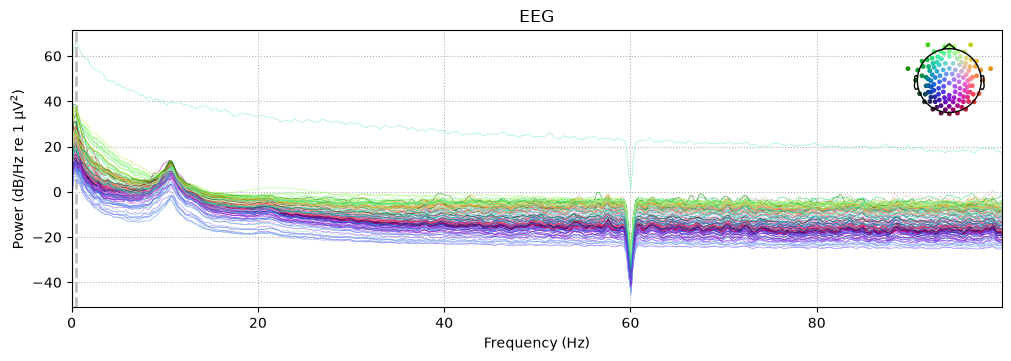

In [4]:
session = pglActions.mneFilter.execute(session=session, lowCutoff=0.5, highCutoff=120.0, notch=True, notchFrequency=60.0)

---

Scratch code

---

In [3]:
session.mne.raw

<RawMff | signal1.bin, 342 x 1658659 (3317.3 s), ~4.23 GiB, data loaded>

In [10]:
stimPicks = mne.pick_types(session.mne.raw.info, meg=False, eeg=False, stim=True)
stimNames = [session.mne.raw.ch_names[i] for i in stimPicks]

for stimName in stimNames:
    stimData = session.mne.raw.get_data(picks=[stimName])[0]
    activeSamples = np.flatnonzero(stimData)
    if activeSamples.size:
        print(f"{stimName}: {activeSamples.size} nonzero samples, first at {activeSamples[0] / session.mne.raw.info['sfreq']:.3f} s, values={np.unique(stimData)}")

DI83: 18 nonzero samples, first at 8.608 s, values=[0. 1.]
D127: 197 nonzero samples, first at 8.612 s, values=[0. 2.]
D255: 2770 nonzero samples, first at 8.614 s, values=[0. 3.]
D121: 15 nonzero samples, first at 9.648 s, values=[0. 4.]
D193: 70 nonzero samples, first at 10.648 s, values=[0. 5.]
DIN1: 241 nonzero samples, first at 10.650 s, values=[0. 6.]
DI31: 63 nonzero samples, first at 10.652 s, values=[0. 7.]
D241: 86 nonzero samples, first at 11.666 s, values=[0. 8.]
DI97: 14 nonzero samples, first at 11.668 s, values=[0. 9.]
D111: 43 nonzero samples, first at 11.670 s, values=[ 0. 10.]
D254: 398 nonzero samples, first at 12.680 s, values=[ 0. 11.]
D192: 42 nonzero samples, first at 12.682 s, values=[ 0. 12.]
D131: 20 nonzero samples, first at 12.684 s, values=[ 0. 13.]
D191: 129 nonzero samples, first at 12.686 s, values=[ 0. 14.]
DI95: 74 nonzero samples, first at 13.714 s, values=[ 0. 15.]
D205: 18 nonzero samples, first at 14.748 s, values=[ 0. 16.]
D163: 16 nonzero samples

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def plotTriggers(raw, channelNames, startTime=0, duration=10):
    startSample = max(0, int(startTime * raw.info["sfreq"]))
    stopSample = min(raw.n_times, int((startTime + duration) * raw.info["sfreq"]))

    if not channelNames or stopSample <= startSample:
        raise ValueError("Choose at least one channel and a valid time window")

    triggerData = raw.get_data(picks=channelNames, start=startSample, stop=stopSample)
    plotTimes = np.arange(startSample, stopSample) / raw.info["sfreq"]
    fig, axes = plt.subplots(len(channelNames), 1, sharex=True, figsize=(14, max(3, 1.5 * len(channelNames))), squeeze=False)

    for ax, channelName, channelData in zip(axes[:, 0], channelNames, triggerData):
        ax.step(plotTimes, channelData, where="post")
        ax.set_ylabel(channelName, rotation=0, ha="right")
        ax.grid(True, alpha=0.3)

    axes[-1, 0].set_xlabel("Time from recording start (s)")
    fig.tight_layout()
    plt.show()

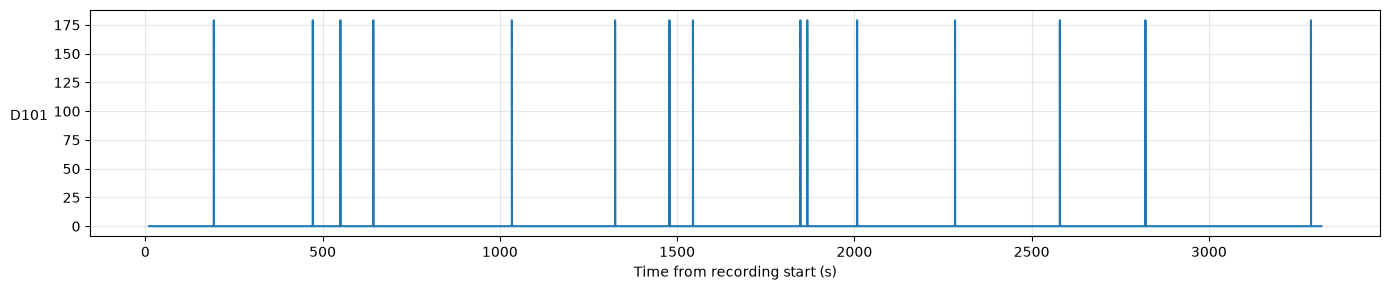

In [33]:
plotTriggers(session.mne.raw, ["D101"], startTime=10, duration=4000)

2736 intervals; mean: 1018.65 ms; median: 1018.00 ms


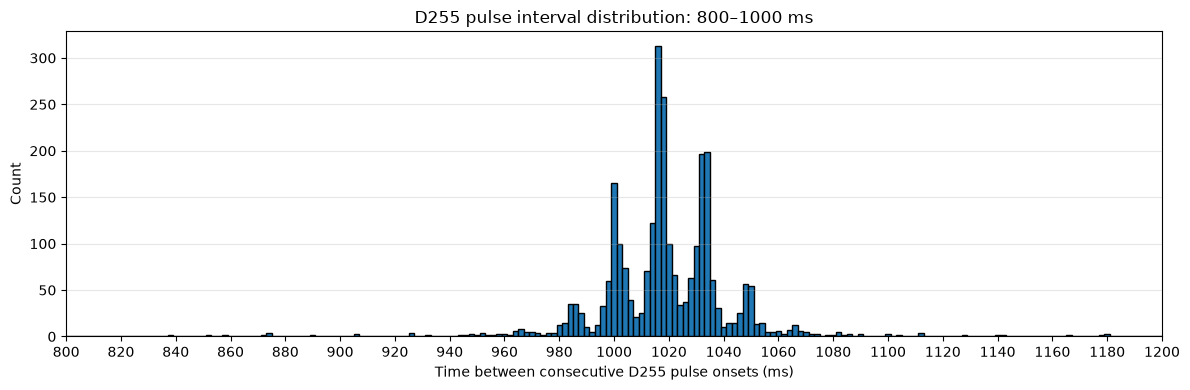

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Detect rising edges of D255 pulses.
triggerData = session.mne.raw.get_data(picks=["D255"])[0]
pulseSamples = np.flatnonzero(np.diff((triggerData != 0).astype(int), prepend=0) == 1)

# Calculate intervals in milliseconds and select 800–1000 ms.
pulseIntervalsMs = np.diff(pulseSamples) / session.mne.raw.info["sfreq"] * 1000
zoomIntervals = pulseIntervalsMs[(pulseIntervalsMs >= 800) & (pulseIntervalsMs <= 1200)]

if zoomIntervals.size:
    print(f"{len(zoomIntervals)} intervals; mean: {zoomIntervals.mean():.2f} ms; median: {np.median(zoomIntervals):.2f} ms")

    # Center bins on the 2 ms sampling grid at 500 Hz.
    sampleMs = 1000 / session.mne.raw.info["sfreq"]
    binEdges = np.arange(800 - sampleMs / 2, 1200 + sampleMs, sampleMs)

    plt.figure(figsize=(12, 4))
    plt.hist(zoomIntervals, bins=binEdges, edgecolor="black")
    plt.xlim(900, 1200)
    plt.xticks(np.arange(800, 1201, 20))
    plt.xlabel("Time between consecutive D255 pulse onsets (ms)")
    plt.ylabel("Count")
    plt.title("D255 pulse interval distribution: 800–1000 ms")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No pulse intervals between 800 and 1000 ms")

In [23]:
stimNames = [name for name, channelType in zip(session.mne.raw.ch_names, session.mne.raw.get_channel_types()) if channelType == "stim"]
print(stimNames)
print(getattr(session.mne.raw, "event_id", None))

['DI83', 'D127', 'D255', 'D121', 'D193', 'DIN1', 'DI31', 'D241', 'DI97', 'D111', 'D254', 'D192', 'D131', 'D191', 'DI95', 'D205', 'D163', 'D239', 'D253', 'D221', 'DI82', 'DI63', 'D235', 'DI93', 'D223', 'D107', 'D184', 'D249', 'DI81', 'DI87', 'D197', 'D129', 'D136', 'D251', 'DI91', 'D252', 'D244', 'D247', 'D250', 'D194', 'D199', 'D201', 'D203', 'D207', 'DI62', 'D218', 'DI90', 'D213', 'DI85', 'DI57', 'D179', 'D125', 'D211', 'D225', 'D195', 'DI75', 'D237', 'D105', 'D172', 'D182', 'DI60', 'D189', 'DIN3', 'D248', 'DI64', 'DI71', 'D104', 'DI56', 'D246', 'DI84', 'D181', 'D122', 'D108', 'D220', 'D169', 'D183', 'DI55', 'D240', 'D208', 'D215', 'D232', 'DI72', 'DIN7', 'DIN5', 'D128', 'D159', 'D100', 'D103', 'D149', 'D188', 'D234', 'D170', 'D242', 'D178', 'DI96', 'D167', 'DI79', 'D123', 'DI99', 'D231', 'D202', 'D138', 'D166', 'DI86', 'D228', 'D168', 'D229', 'D155', 'D116', 'D164', 'D153', 'D238', 'DI78', 'DI92', 'DI69', 'D139', 'D210', 'D165', 'D217', 'D219', 'D154', 'DI74', 'D135', 'D176', 'D243',

Finding events on: D255
2770 events found on stim channel D255
Event IDs: [3]
Not setting metadata
2770 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 2770 events and 501 original time points ...
0 bad epochs dropped
Detected 2770 D255 onsets; retained 2770 epochs


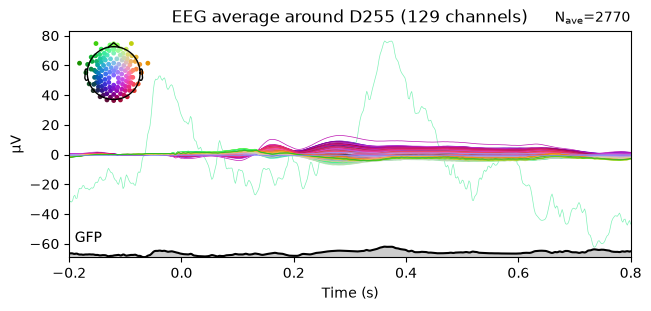

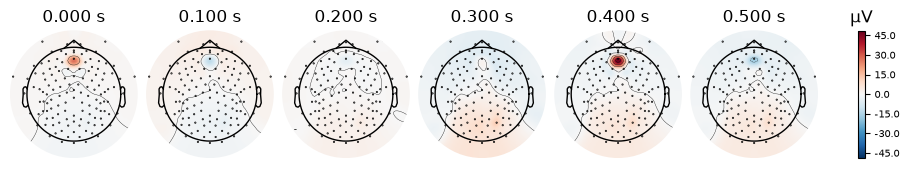

In [ ]:
import mne

# Detect D255 onsets, including single-sample events.
events = mne.find_events(session.mne.raw, stim_channel="D255", output="onset", consecutive=True, shortest_event=1, initial_event=True)

if len(events):
    # Epoch EEG channels and baseline-correct using the 200 ms before D255.
    epochs = mne.Epochs(session.mne.raw, events, event_id=None, tmin=-0.2, tmax=0.8, baseline=(-0.2, 0), picks="eeg", preload=True, reject_by_annotation=True)

    print(f"Detected {len(events)} D255 onsets; retained {len(epochs)} epochs")

    if len(epochs):
        evoked = epochs.average()

        # Butterfly plot: all retained EEG channels overlaid.
        evoked.plot(spatial_colors=True, gfp=True, time_unit="s", ylim={"eeg": (-10, 10)}, titles="EEG average around D255")

        # Scalp voltage maps at selected post-trigger times, in seconds.
        evoked.plot_topomap(times=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5], ch_type="eeg", time_unit="s", colorbar=True)
    else:
        print("No usable epochs remain; check annotations and recording boundaries")
else:
    print("No D255 onsets found")